In [1]:
from src import *
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

data = get_combined_data()
sim_params = SimulationParameters("default_1")
sim_handler = SimulatorHandler()
gap_handler = sim_handler.simulation_gap(sim_params, data)

The target default_1 already exists and will be overwritten


In [2]:
action_gaps = {"combined" : []}
for action, gap_datas in gap_handler._sim_gap_data.items():
    action_gaps[action] = []
    for gap_data in gap_datas:
        gap = gap_data.get_total_gap_avg()
        action_gaps[action].append(gap)
        action_gaps["combined"].append(gap)
for gaps in action_gaps.values():
    gaps.sort()
for action, gaps in action_gaps.items():
    p_25 = np.percentile(gaps, 25)
    p_50 = np.percentile(gaps, 50)
    p_75 = np.percentile(gaps, 75)
    print(action + ": " + str(p_25) + ", " + str(p_50) + ", " + str(p_75))

combined: 0.010045201857653806, 0.011801790328722712, 0.020281270317243676
kick_left: 0.017073699873785694, 0.01894833198705318, 0.020011594280381514
kick_right: 0.021215685034469824, 0.022857082774477705, 0.024937501137247665
walk_front: 0.008388185237208069, 0.009150827249750243, 0.010108271231102502
walk_back: 0.009952779565285815, 0.010262832643699656, 0.01229994749432457
sidestep_left: 0.00979677529637244, 0.010258617573798435, 0.010607815037185487
sidestep_right: 0.009379342792743078, 0.009588069456463373, 0.009923492409246797
turn_left: 0.009776326758933487, 0.01050130694407055, 0.011321025358570535
turn_right: 0.010350639950534181, 0.010602364930373153, 0.01131617211030454
standup_back: 0.013622467237671892, 0.022927669798914096, 0.029067264397534896
standup_front: 0.021700060067948196, 0.022688669431696822, 0.027963817006875925


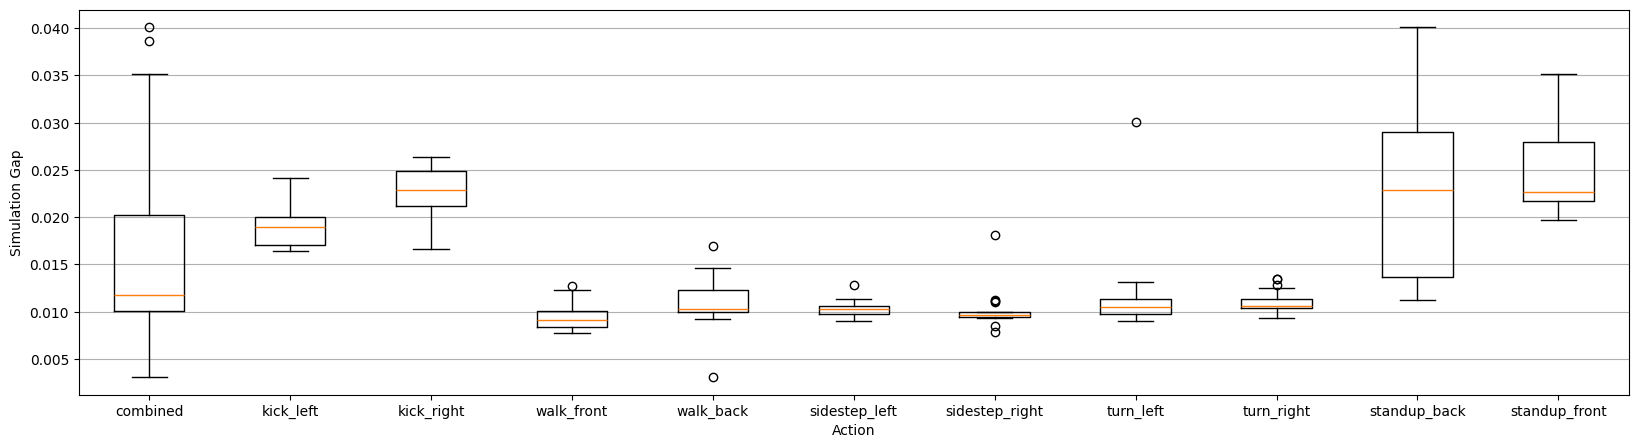

In [3]:
plt.figure(figsize=(20, 5))
plt.xlabel("Action")
plt.ylabel("Simulation Gap")
plt.grid(visible=True, axis="y")
plt.boxplot(action_gaps.values(), tick_labels=action_gaps.keys())
plt.savefig("action_gaps.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()

kick_left


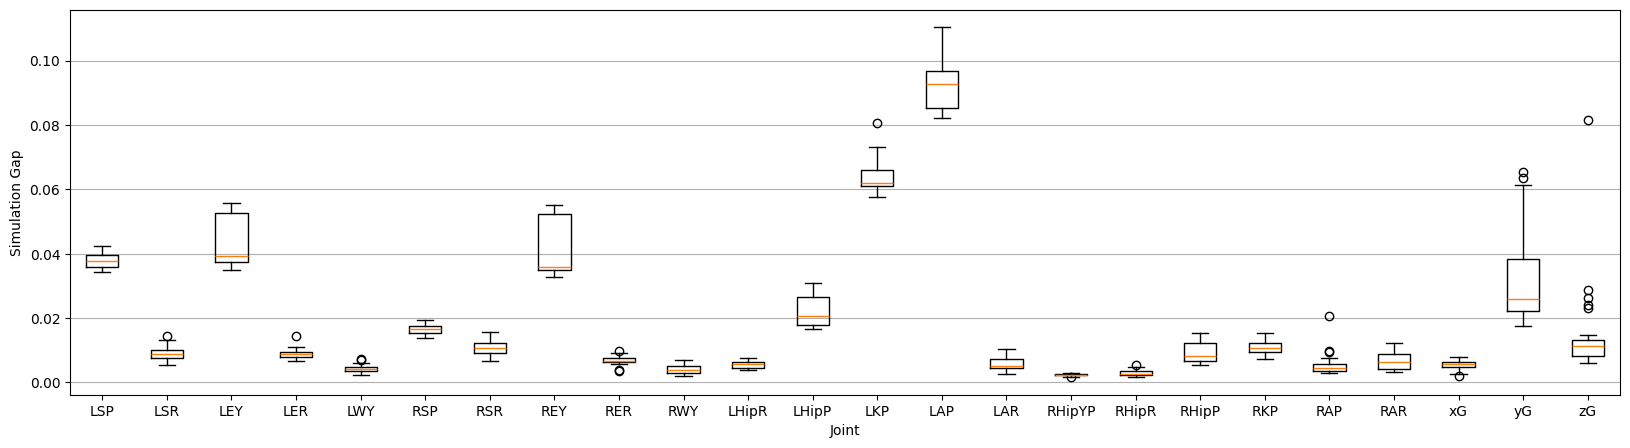

kick_right


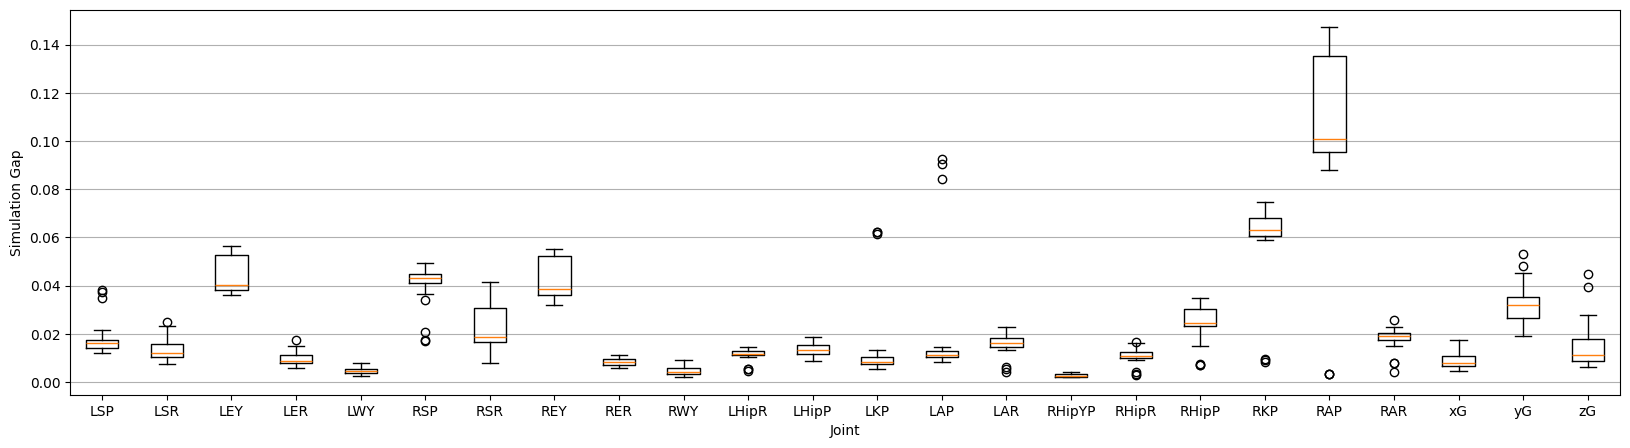

walk_front


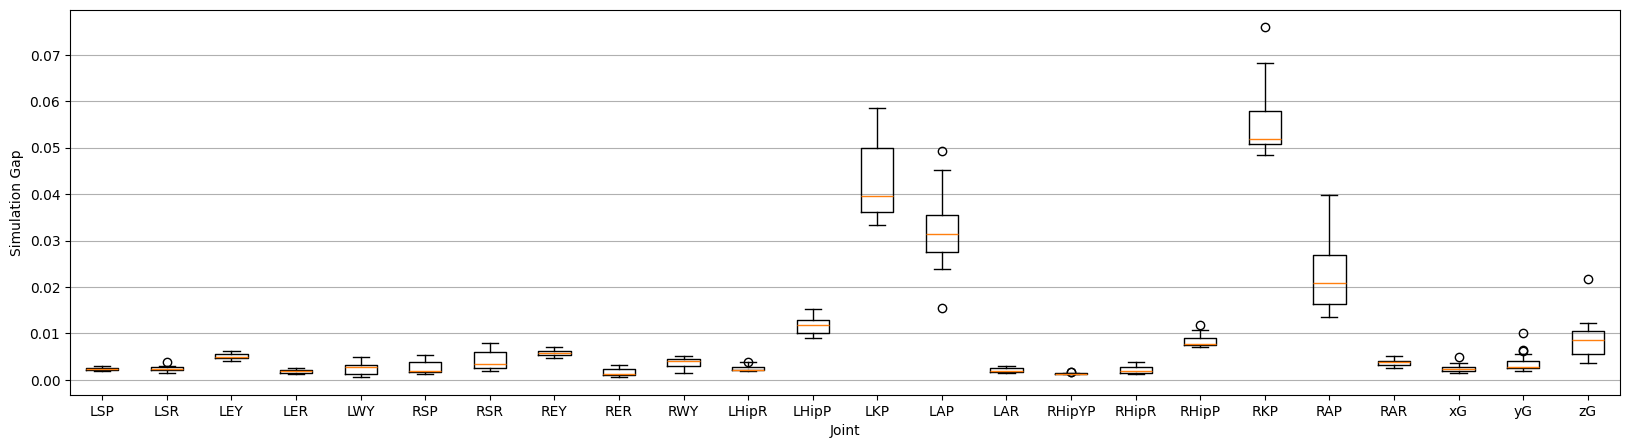

walk_back


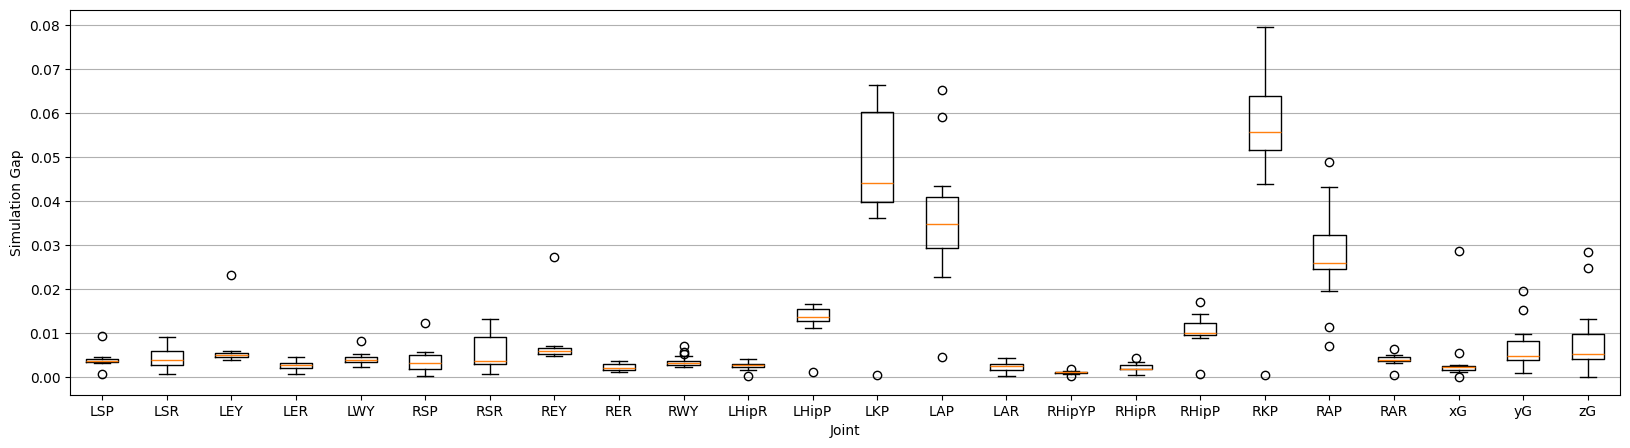

sidestep_left


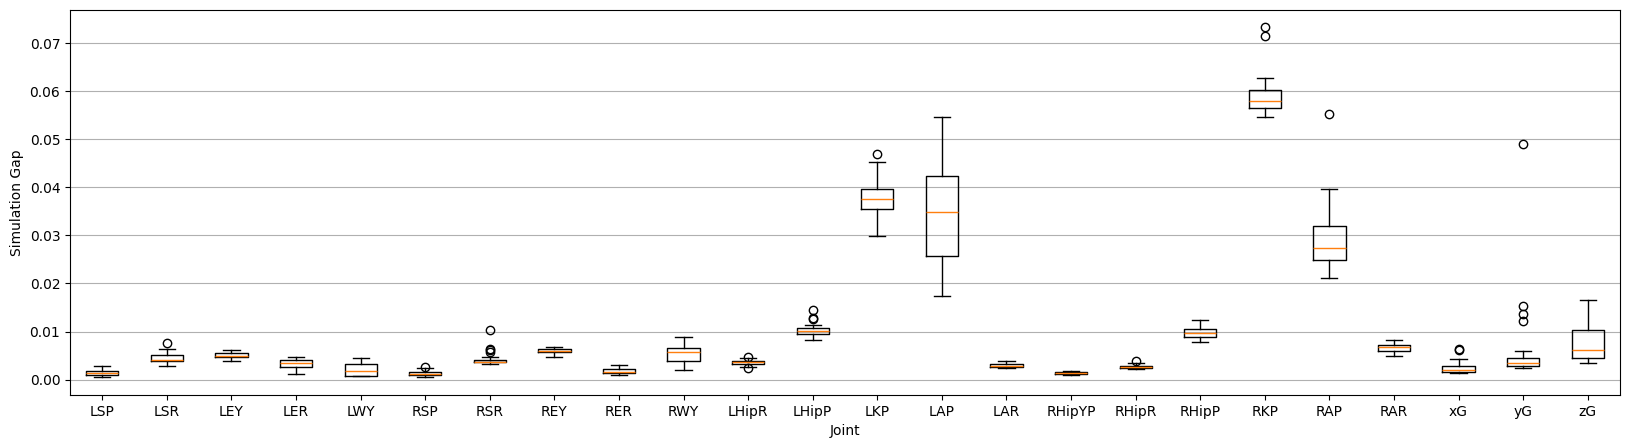

sidestep_right


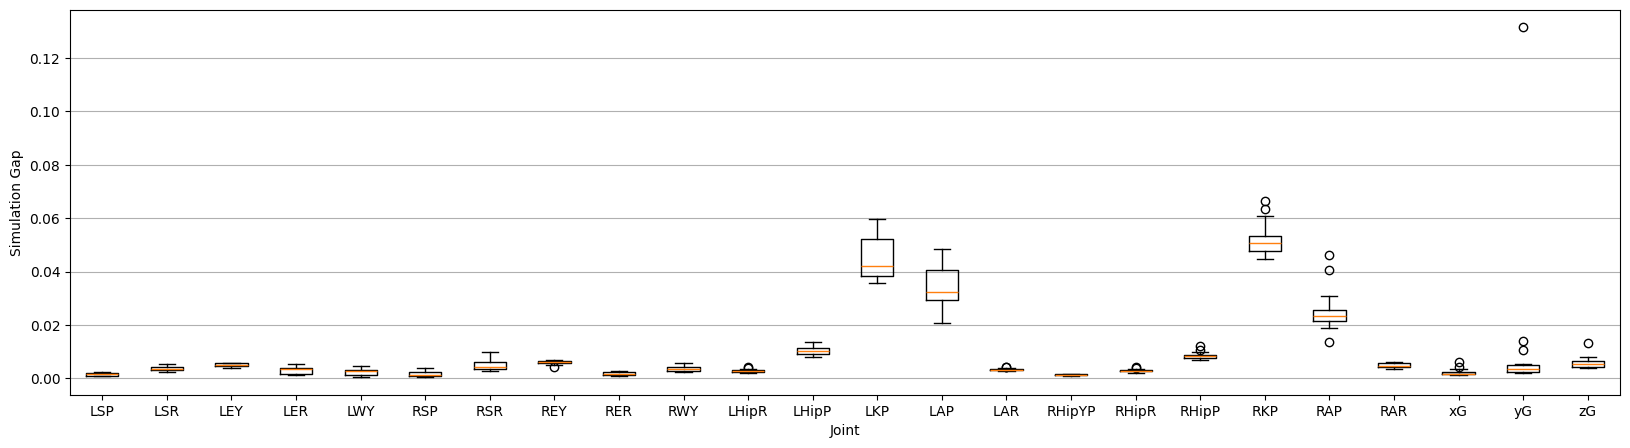

turn_left


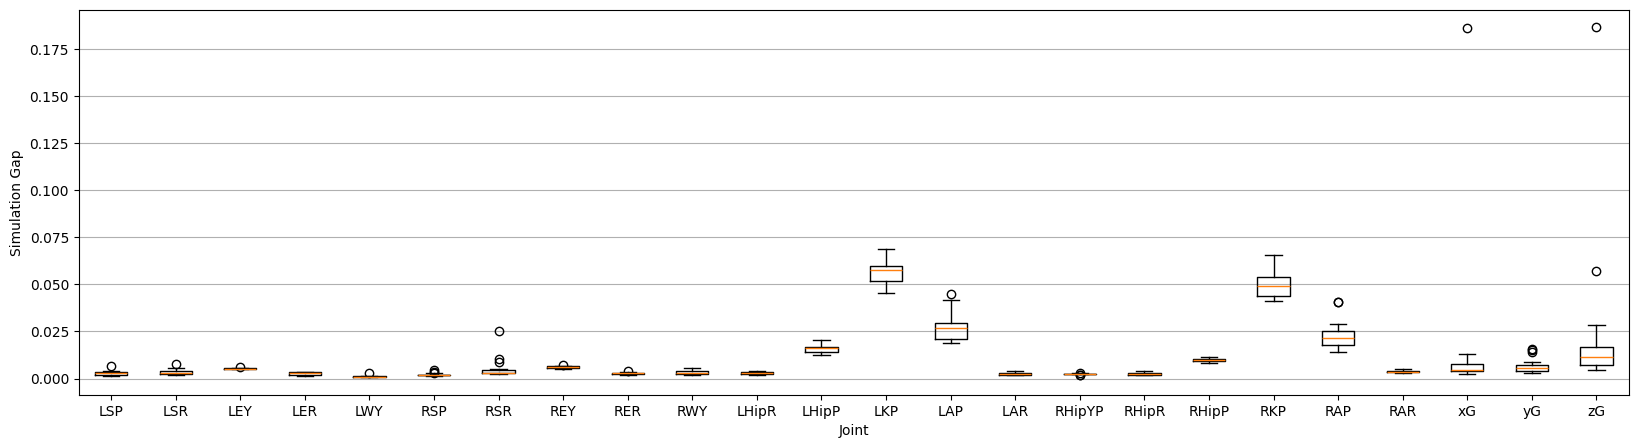

turn_right


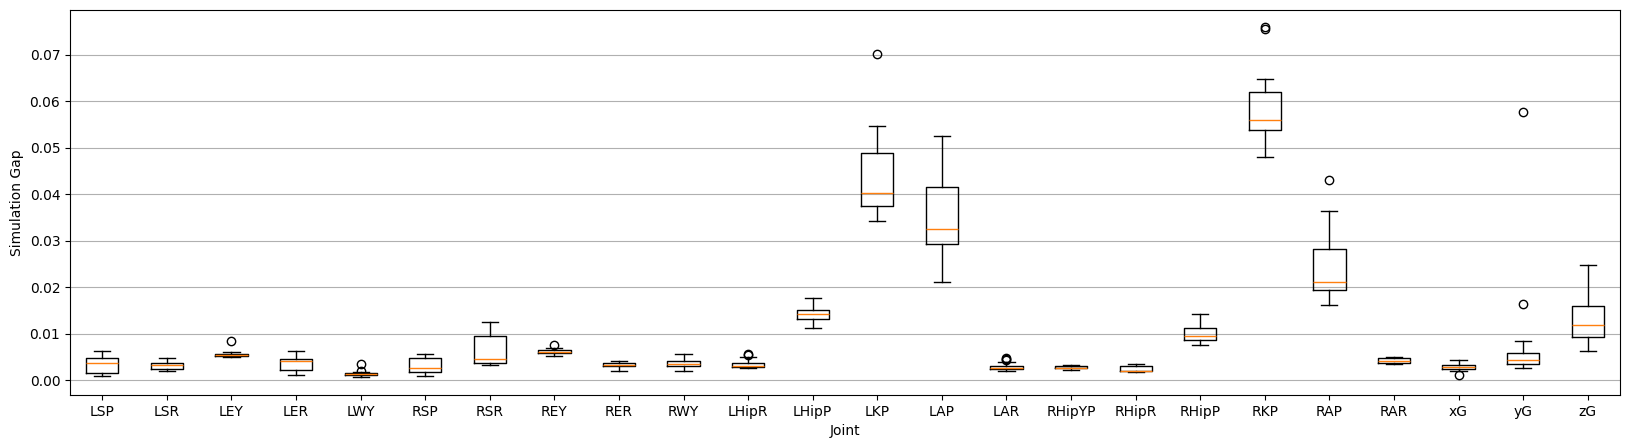

standup_back


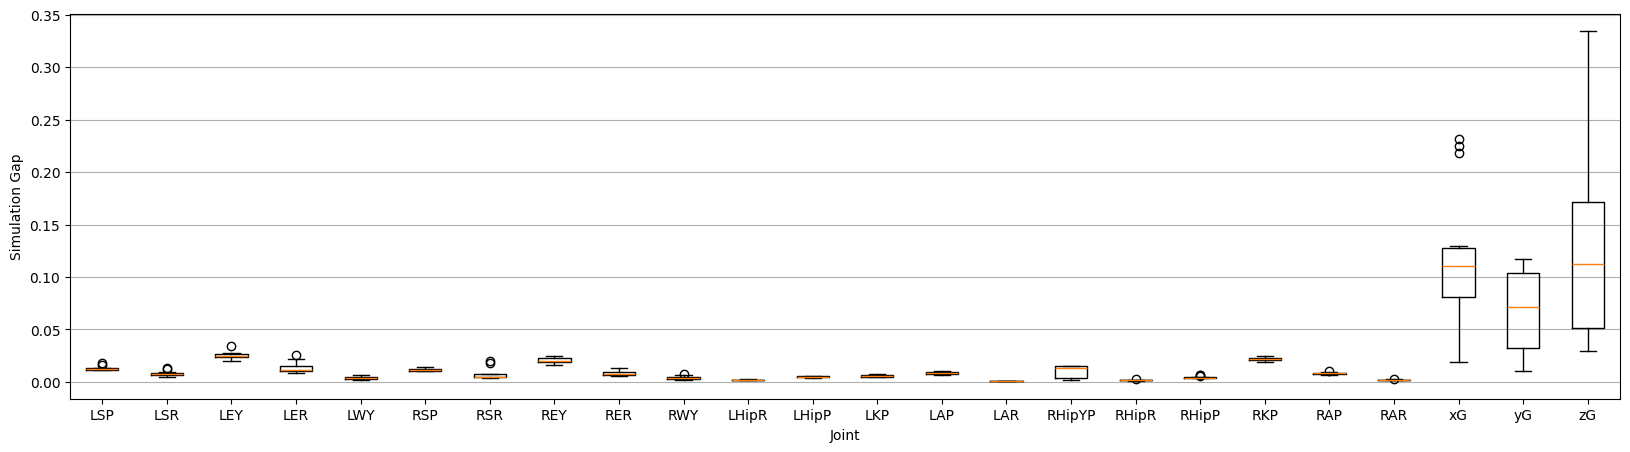

standup_front


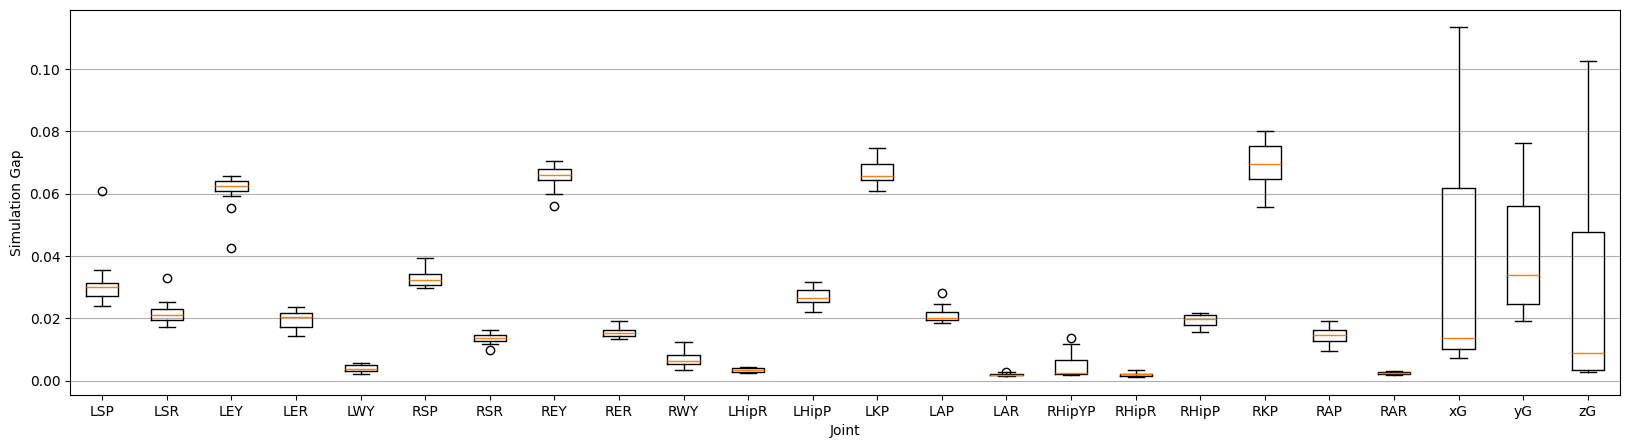

In [4]:
excluded_sensors = ["headYaw", "headPitch", "lHipYawPitch"]

for action, gap_datas in gap_handler._sim_gap_data.items():
    sensor_gaps = {}
    for gap_data in gap_datas:
        sensor_gap = gap_data.get_total_gap_for_sensors()
        for key,value in sensor_gap.items():
            if key in excluded_sensors:
                continue
            if not key in sensor_gaps.keys():
                sensor_gaps[key] = []
            sensor_gaps[key].append(sensor_gap[key])
    print(action)
    plt.figure(figsize=(20, 5))
    plt.xlabel("Joint")
    plt.ylabel("Simulation Gap")
    plt.grid(visible=True, axis="y")
    plt.boxplot(sensor_gaps.values(), tick_labels=[ABBREVIATIONS[key] for key in sensor_gaps.keys()])
    plt.savefig(action + "_gaps.pdf", bbox_inches='tight', pad_inches=0.1)
    plt.show()

KeyError: 'combined'

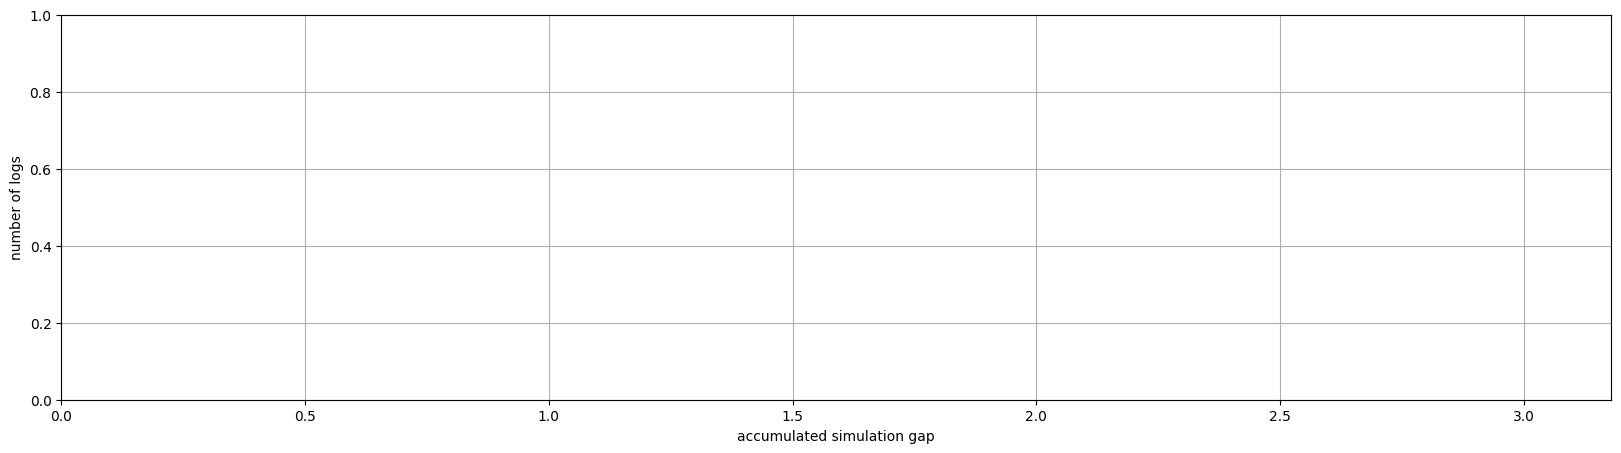

In [5]:
accumulated_gaps = {}
for action, gaps in action_gaps.items():
    accumulated_gaps[action] = np.cumsum(gaps)
gaps_y_axis = {action : list(range(0, len(gaps))) for action, gaps in accumulated_gaps.items()}


keys = accumulated_gaps.keys()
max_value = max([accumulated_gap[-1] for action, accumulated_gap in accumulated_gaps.items() if action in keys])
keys_2 = ["walk_front","sidestep_left","turn_left","walk_back","sidestep_right","turn_right"]
max_value_2 = max([accumulated_gap[-1] for action, accumulated_gap in accumulated_gaps.items() if action in keys_2])

plt.figure(figsize=(20, 5))
plt.xlabel("accumulated simulation gap")
plt.ylabel("number of logs")
plt.xlim(0, max_value*1.01)
plt.grid(visible=True)
for action in keys:
    accumulated_gap = accumulated_gaps[action]
    y_axis = gaps_y_axis[action]
    plt.plot(accumulated_gap, y_axis, label=action, color = COLORS[action], marker = "x")
plt.legend()
plt.show()

plt.figure(figsize=(20, 5))
plt.xlabel("accumulated simulation gap")
plt.ylabel("number of logs")
plt.grid(visible=True)
for action in keys_2:
    accumulated_gap = accumulated_gaps[action]
    y_axis = gaps_y_axis[action]
    plt.plot(accumulated_gap, y_axis, label=action, color = COLORS[action], marker = "x")
plt.xlim(0, max_value_2*1.01)
plt.legend()
plt.show()